In [1]:
import pandas as pd

data = pd.read_csv(
    "F:/AI Project/churn-retention-platform/data/processed/dataset_week4_transactional_behavioral_final.csv"
)

data.head()


,msno,is_churn,total_amount_paid,num_transactions,num_cancellations,total_plan_days,long_num_25,mid_num_25,recent_num_25,long_num_50,...,recent_num_985,long_num_100,mid_num_100,recent_num_100,long_num_unq,mid_num_unq,recent_num_unq,long_total_secs,mid_total_secs,recent_total_secs
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1,298.0,2.0,0.0,60.0,2.0,14.0,12.0,0.0,...,6.0,31.0,220.0,180.0,22.0,123.0,102.0,8304.385,61003.350,51031.900
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1,149.0,1.0,0.0,30.0,93.0,141.0,121.0,67.0,...,43.0,1969.0,1439.0,1055.0,1902.0,1596.0,1334.0,476142.077,358898.544,281293.581
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1,0.0,0.0,0.0,0.0,200.0,408.0,385.0,86.0,...,49.0,860.0,884.0,1265.0,768.0,886.0,1403.0,227874.951,273152.183,312991.990
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1,0.0,0.0,0.0,0.0,63.0,149.0,48.0,44.0,...,37.0,3665.0,3368.0,2397.0,3811.0,3564.0,2468.0,961418.681,880715.218,629925.240


In [3]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

data = pd.read_csv(
    "F:/AI Project/churn-retention-platform/data/processed/dataset_week4_transactional_behavioral_final.csv"
)


X = data.drop(columns=["msno", "is_churn"])
y = data["is_churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

val_preds = final_model.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, val_preds)


def risk_bucket(prob):
    if prob < 0.3:
        return "Low"
    elif prob < 0.6:
        return "Medium"
    else:
        return "High"


data["churn_probability"] = final_model.predict_proba(X)[:, 1]
data["risk_segment"] = data["churn_probability"].apply(risk_bucket)


importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

print(f"ROC:{roc} &\n\n Importance of features in this model:\n\n:{importance_df.head(25)}")



[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5500
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5500
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

F:\AI Project\churn-retention-platform\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


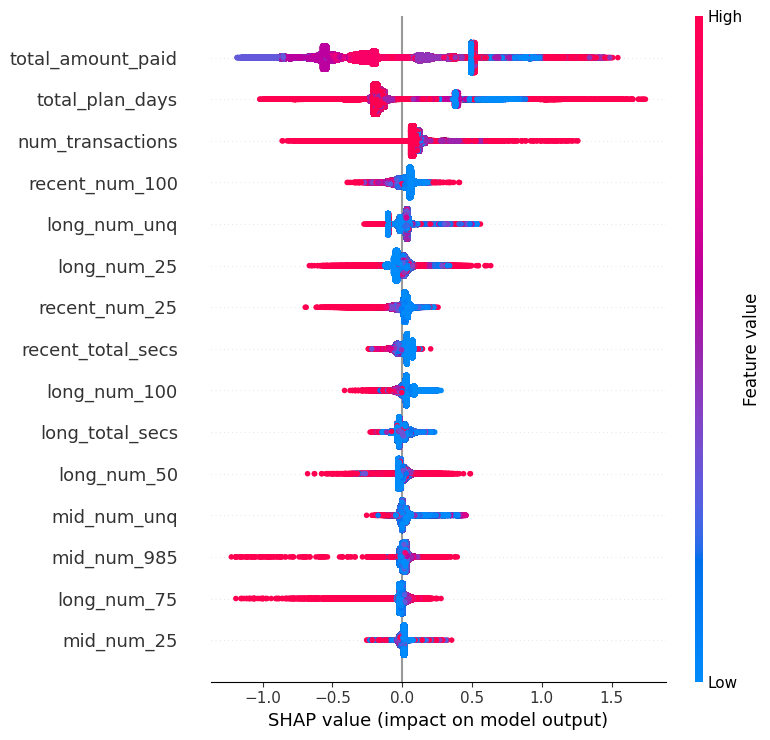

In [1]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap


data = pd.read_csv(
    "F:/AI Project/churn-retention-platform/data/processed/dataset_week4_transactional_behavioral_final.csv"
)


X = data.drop(columns=["msno", "is_churn"])
y = data["is_churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

val_preds = final_model.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, val_preds)


def risk_bucket(prob):
    if prob < 0.3:
        return "Low"
    elif prob < 0.6:
        return "Medium"
    else:
        return "High"


data["churn_probability"] = final_model.predict_proba(X)[:, 1]
data["risk_segment"] = data["churn_probability"].apply(risk_bucket)


explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X,
    max_display=15
)





[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5500
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

F:\AI Project\churn-retention-platform\venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


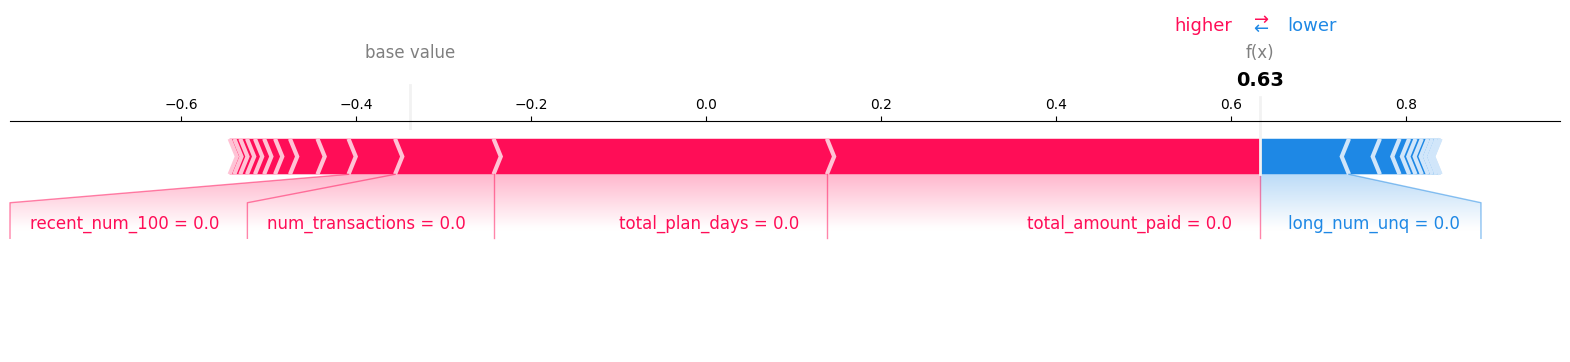

In [2]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap


data = pd.read_csv(
    "F:/AI Project/churn-retention-platform/data/processed/dataset_week4_transactional_behavioral_final.csv"
)


X = data.drop(columns=["msno", "is_churn"])
y = data["is_churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

val_preds = final_model.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, val_preds)


def risk_bucket(prob):
    if prob < 0.3:
        return "Low"
    elif prob < 0.6:
        return "Medium"
    else:
        return "High"


data["churn_probability"] = final_model.predict_proba(X)[:, 1]
data["risk_segment"] = data["churn_probability"].apply(risk_bucket)


explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)


user_index = 0  # try different users

shap.force_plot(
    explainer.expected_value,
    shap_values[user_index],
    X.iloc[user_index],
    matplotlib=True
)


In [3]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap


data = pd.read_csv(
    "F:/AI Project/churn-retention-platform/data/processed/dataset_week4_transactional_behavioral_final.csv"
)


X = data.drop(columns=["msno", "is_churn"])
y = data["is_churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

val_preds = final_model.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, val_preds)


def risk_bucket(prob):
    if prob < 0.3:
        return "Low"
    elif prob < 0.6:
        return "Medium"
    else:
        return "High"


data["churn_probability"] = final_model.predict_proba(X)[:, 1]
data["risk_segment"] = data["churn_probability"].apply(risk_bucket)


high_risk_users = data[data["risk_segment"] == "High"]

print(f"high_risk_users_head:\n\n{high_risk_users[["msno", "churn_probability"]].head()} \n\n & \n\n User_Risk_Percentage:\n\n{data["risk_segment"].value_counts(normalize=True)
}")



[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5500
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [4]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import shap
import joblib


data = pd.read_csv(
    "F:/AI Project/churn-retention-platform/data/processed/dataset_week4_transactional_behavioral_final.csv"
)


X = data.drop(columns=["msno", "is_churn"])
y = data["is_churn"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

val_preds = final_model.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, val_preds)


def risk_bucket(prob):
    if prob < 0.3:
        return "Low"
    elif prob < 0.6:
        return "Medium"
    else:
        return "High"


data["churn_probability"] = final_model.predict_proba(X)[:, 1]
data["risk_segment"] = data["churn_probability"].apply(risk_bucket)


data.to_csv(
    "F:/AI Project/churn-retention-platform/data/processed/user_churn_scored_week5.csv",
    index=False
)


joblib.dump(
    final_model,
    "F:/AI Project/churn-retention-platform/models/churn_model_week5.pkl"
)

print("Data & Model - Both are saved")


[LightGBM] [Info] Number of positive: 50777, number of negative: 743567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5500
[LightGBM] [Info] Number of data points in the train set: 794344, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g